# Visualisierung der gefundenen Zahlen

Dieses Notebook erstellt Diagramme für die gefundenen Zahlen aus der CSV-Datei:
- **Primzahlfunktion π(n)**: Anzahl der Primzahlen ≤ n
- **Logarithmus log(n)**: Natürlicher Logarithmus von n

In [1]:
# SageMath Imports
from sage.all import *
import csv

print("✓ SageMath erfolgreich geladen!")
print(f"SageMath Version: {version()}")
sys.stdout.flush()

✓ SageMath erfolgreich geladen!
SageMath Version: SageMath version 10.8, Release Date: 2025-12-18


## Konfiguration

In [2]:
# CSV-Datei zum Lesen
csv_file = "quadratfreie_tupel_mod12.csv"

# Ausgabedatei für das Diagramm
output_file = "quadratfreie_tupel_plot.png"

print(f"Konfiguration:")
print(f"  CSV-Datei: {csv_file}")
print(f"  Ausgabedatei: {output_file}")
sys.stdout.flush()

Konfiguration:
  CSV-Datei: quadratfreie_tupel_mod12.csv
  Ausgabedatei: quadratfreie_tupel_plot.png


## Daten einlesen

In [3]:
# Lese CSV-Datei
print(f"Lese Daten aus '{csv_file}'...")
sys.stdout.flush()

numbers = []
try:
    with open(csv_file, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            n_val = int(row["n"])
            numbers.append(n_val)
    print(f"✓ {len(numbers)} Zahlen eingelesen")
    if numbers:
        print(f"  Bereich: {min(numbers)} bis {max(numbers)}")
except FileNotFoundError:
    print(f"✗ Fehler: Datei '{csv_file}' nicht gefunden!")
except Exception as e:
    print(f"✗ Fehler beim Lesen: {e}")

sys.stdout.flush()

Lese Daten aus 'quadratfreie_tupel_mod12.csv'...
✓ 1750 Zahlen eingelesen
  Bereich: 5005 bis 999481


## Berechnung von π(n) und log(n)

In [4]:
if numbers:
    # Sortiere Zahlen
    numbers.sort()
    
    # Berechne π(n) für jede Zahl (Anzahl der Primzahlen ≤ n)
    print("Berechne Primzahlfunktion π(n)...")
    sys.stdout.flush()
    pi_values = [prime_pi(n) for n in numbers]
    
    # Berechne Logarithmus von n
    print("Berechne Logarithmus log(n)...")
    sys.stdout.flush()
    log_values = [log(n) for n in numbers]
    
    print("✓ Berechnungen abgeschlossen")
    sys.stdout.flush()
else:
    pi_values = []
    log_values = []

Berechne Primzahlfunktion π(n)...
Berechne Logarithmus log(n)...
✓ Berechnungen abgeschlossen


## Diagramm erstellen

Erstelle Diagramm...


Matplotlib is building the font cache; this may take a moment.


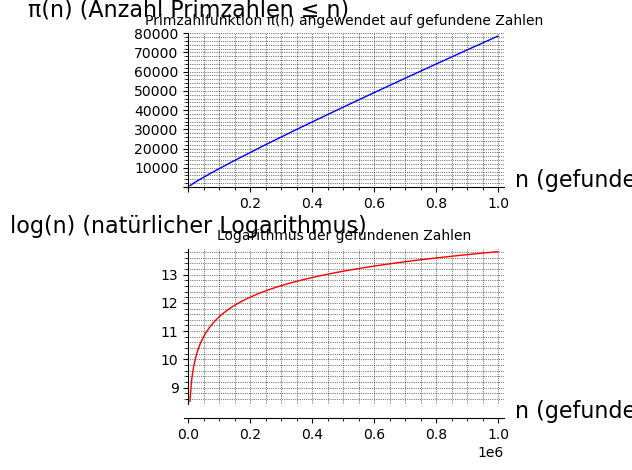

✓ Diagramm gespeichert nach 'quadratfreie_tupel_plot.png'


In [5]:
if numbers and pi_values and log_values:
    print("Erstelle Diagramm...")
    sys.stdout.flush()
    
    # Erstelle Liste von Punkten für π(n)
    points_pi = list(zip(numbers, pi_values))
    plot_pi = list_plot(points_pi, plotjoined=True, color='blue', 
                       axes_labels=['n (gefundene Zahl)', 'π(n) (Anzahl Primzahlen ≤ n)'],
                       title='Primzahlfunktion π(n) angewendet auf gefundene Zahlen',
                       figsize=(12, 5),
                       gridlines='minor')
    
    # Erstelle Liste von Punkten für log(n)
    points_log = list(zip(numbers, log_values))
    plot_log = list_plot(points_log, plotjoined=True, color='red',
                        axes_labels=['n (gefundene Zahl)', 'log(n) (natürlicher Logarithmus)'],
                        title='Logarithmus der gefundenen Zahlen',
                        figsize=(12, 5),
                        gridlines='minor')
    
    # Kombiniere beide Plots
    combined_plot = graphics_array([plot_pi, plot_log], nrows=2, ncols=1)
    
    # Zeige Plot
    show(combined_plot)
    
    # Speichere Diagramm
    combined_plot.save(output_file, figsize=(12, 10), dpi=300)
    print(f"✓ Diagramm gespeichert nach '{output_file}'")
    sys.stdout.flush()
else:
    print("⚠️  Keine Daten zum Plotten verfügbar!")
    sys.stdout.flush()

## Statistiken

In [6]:
if numbers:
    print("=" * 60)
    print("Statistiken:")
    print("=" * 60)
    print(f"Anzahl Zahlen: {len(numbers)}")
    print(f"Minimum: {min(numbers)}")
    print(f"Maximum: {max(numbers)}")
    print(f"\nPrimzahlfunktion π(n):")
    print(f"  π({min(numbers)}) = {prime_pi(min(numbers))}")
    print(f"  π({max(numbers)}) = {prime_pi(max(numbers))}")
    print(f"\nLogarithmus log(n):")
    print(f"  log({min(numbers)}) = {log(min(numbers)):.4f}")
    print(f"  log({max(numbers)}) = {log(max(numbers)):.4f}")
    sys.stdout.flush()

Statistiken:
Anzahl Zahlen: 1750
Minimum: 5005
Maximum: 999481

Primzahlfunktion π(n):
  π(5005) = 670
  π(999481) = 78464

Logarithmus log(n):


TypeError: unsupported format string passed to sage.symbolic.expression.Expression.__format__